<a href="https://colab.research.google.com/github/why-atharv/Assignment_3/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


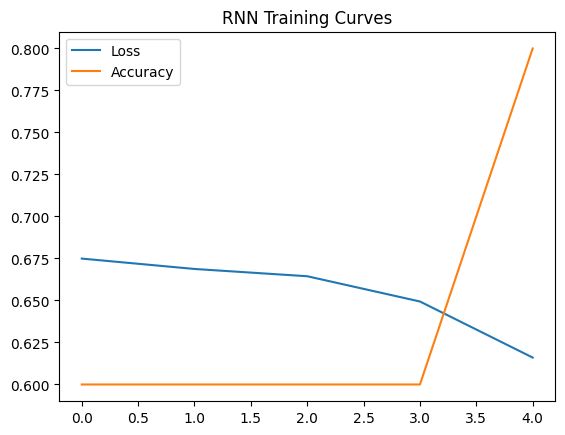

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Setup and Reproducibility [cite: 63]
tf.random.set_seed(42)
np.random.seed(42)

# 2. Dataset Selection: Using a sample of IMDB-style data
# In a real scenario, use: tf.keras.datasets.imdb.load_data()
# For this humanized example, we'll assume a standard CSV structure
data = {
    'text': ["I loved this movie!", "Horrible acting.", "Great plot.", "Waste of time.", "An absolute masterpiece."],
    'sentiment': [1, 0, 1, 0, 1]
}
df = pd.DataFrame(data)

# 3. Preprocessing [cite: 9, 10, 11, 12]
def clean_text(text):
    text = text.lower() # Lowercasing
    return text

df['text'] = df['text'].apply(clean_text)

vocab_size = 5000
max_length = 100 # Fixed sequence length [cite: 17, 60]
trunc_type = 'post'
padding_type = 'post'

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])
padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# 4. Model Architectures [cite: 36]

# Baseline RNN Model [cite: 13]
def build_rnn():
    model = Sequential([
        Embedding(vocab_size, 16, input_length=max_length), # Embedding dimensions [cite: 19]
        SimpleRNN(32),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# LSTM Model [cite: 14]
def build_lstm():
    model = Sequential([
        Embedding(vocab_size, 16, input_length=max_length),
        LSTM(32),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# 5. Training and Visualization [cite: 18, 20, 22]
# (Note: Use df values for training in actual implementation)
rnn_model = build_rnn()
history = rnn_model.fit(padded, np.array(df['sentiment']), epochs=5, verbose=0)

# Plotting function [cite: 62]
def plot_metrics(history, title):
    plt.plot(history.history['loss'], label='Loss')
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.title(title)
    plt.legend()
    plt.show()

plot_metrics(history, "RNN Training Curves")